In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Exploratory Data Analysis On Initial Data

### Exploratory Data Analysis FER2013

In [3]:
def read_fer_raw(folder_path):
    initial_fer_data = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root,f)
                img = cv2.imread(img_path)
                if img is not None:
                    label = os.path.basename(root).lower()
                    initial_fer_data.append((img, label))
    return initial_fer_data

In [4]:
FER_folder_path = r'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Raw Dataset\FER2013\FER2013'

In [5]:
initial_fer_data = read_fer_raw(FER_folder_path)
print(f"Jumlah Dataset FER2013 sebelum preprocessing : {len(initial_fer_data)}")

Jumlah Dataset FER2013 sebelum preprocessing : 35887


### Exploratory Data Analysis KDEF

In [6]:
def map_kdef_label(label_code):
    mapping = {
        'AF': 'fear',      
        'AN': 'angry',
        'DI': 'disgust',
        'HA': 'happy',
        'NE': 'neutral',
        'SA': 'sad',
        'SU': 'surprise',
        'V' : 'unknown',
        'H': 'unknown'
    }
    return mapping.get(label_code.upper(), label_code)

In [7]:
def read_kdef_raw(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                name, _ = os.path.splitext(filename)
                if len(name) > 0 :
                    emotion_code = name[4:6].upper()
                    label = map_kdef_label(emotion_code)
                    img_path = os.path.join(root, filename)
                    img = cv2.imread(img_path)
                    if img is not None:
                        data.append((img, label))      
    return data

In [8]:
KDEF_folder_path = r'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Raw Dataset\KDEF_and_AKDEF\KDEF'

In [9]:
initial_kdef_data = read_kdef_raw(KDEF_folder_path)
print(f"Jumlah Dataset KDEF Sebelum Preprocessing: {len(initial_kdef_data)}")

Jumlah Dataset KDEF Sebelum Preprocessing: 4900


### Exploratory Data Analysis CK+

In [10]:
def read_ckplus_raw(folder_path):
    initial_ckplus_data = []
    label_map = {
        'anger': 'angry',
        'sadness': 'sad'
    }

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    label = os.path.basename(root).lower()
                    label = label_map.get(label, label)  
                    initial_ckplus_data.append((img, label))
    return initial_ckplus_data

In [11]:
CK_folder_path = r'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Raw Dataset\CK+'
initial_ckplus_data = read_ckplus_raw(CK_folder_path)
print(f"Jumlah Dataset CK+ sebelum preprocessing : {len(initial_ckplus_data)}")

Jumlah Dataset CK+ sebelum preprocessing : 981


### Exploratory Data Analysis Total (Sebelum Preprocessing)

In [12]:
combined_raw_dataset = initial_fer_data + initial_ckplus_data + initial_kdef_data
print(f"Total Keseluruhan Dataset Sebelum Preprocessing : {len(combined_raw_dataset)}")

Total Keseluruhan Dataset Sebelum Preprocessing : 41768


Jumlah data per label sebelum dilakukan preprocessing:
happy: 9896
neutral: 6898
sad: 6860
fear: 5896
angry: 5788
surprise: 4950
disgust: 1424
contempt: 54
unknown: 2


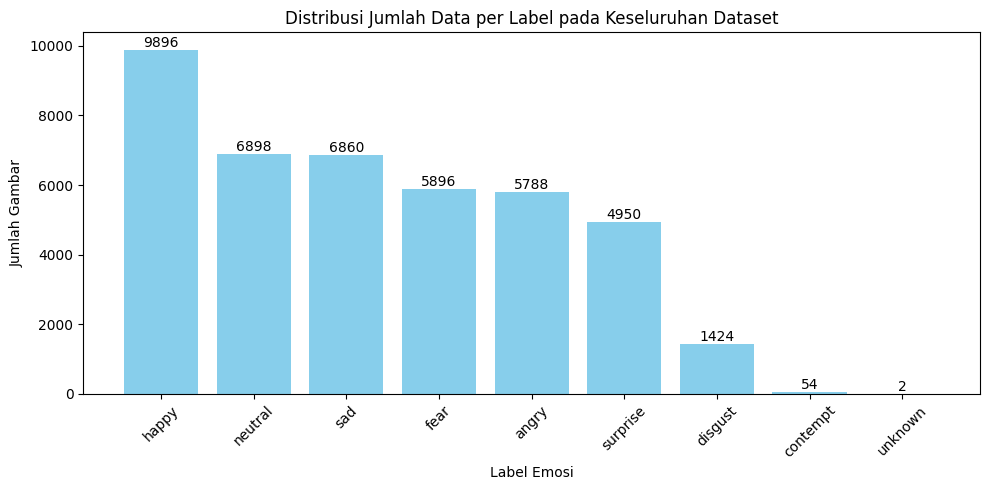

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

all_labels = [label for _, label in combined_raw_dataset]

label_counts = Counter(all_labels)
sorted_label_counts = label_counts.most_common()

print("Jumlah data per label sebelum dilakukan preprocessing:")
for label, count in sorted_label_counts:
    print(f"{label}: {count}")

labels_sorted, values = zip(*sorted_label_counts)

plt.figure(figsize=(10, 5))

bars = plt.bar(labels_sorted, values, color='skyblue')
plt.bar_label(bars)

plt.title('Distribusi Jumlah Data per Label pada Keseluruhan Dataset')
plt.xlabel('Label Emosi')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================= 
### LOAD DATASET FER2013 SETELAH FILTERING GAMBAR SKETSA DAN GAMBAR TIDAK RELEVAN SECARA MANUAL
# ============================= 

In [14]:
def read_fer_dataset(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    label = os.path.basename(root)
                    data.append((img, label))
    return data

In [15]:
FER_folder_path = r'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Used Dataset\FER2013' 
fer_dataset = read_fer_dataset(FER_folder_path)

In [16]:
print(f"Jumlah Dataset FER2013 : {len(fer_dataset)}")

Jumlah Dataset FER2013 : 35647


### Display FER2013

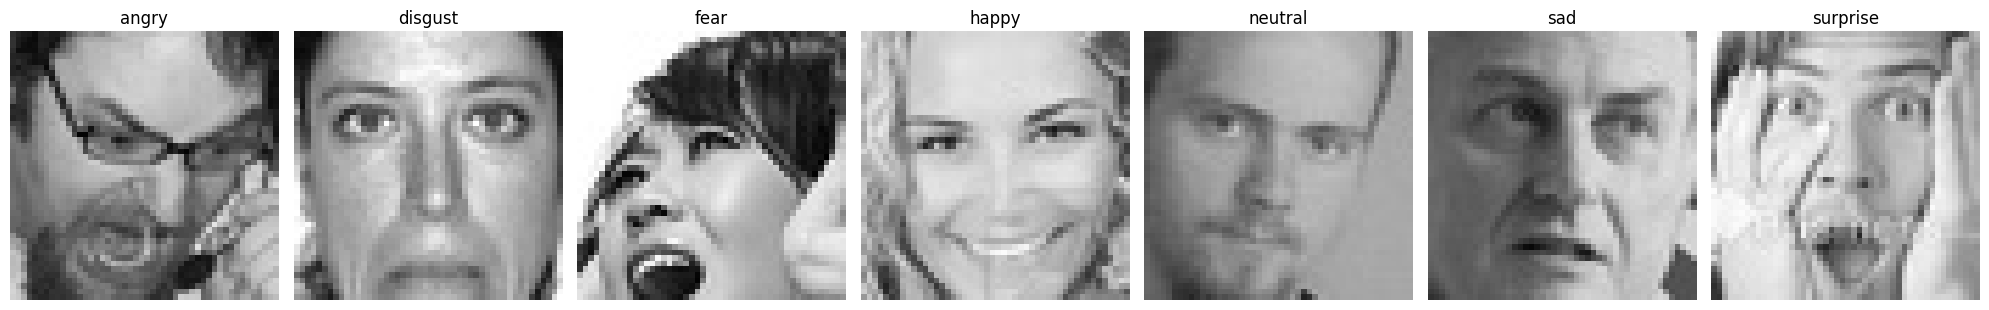

In [17]:
label_images = {}

for img, label in fer_dataset:
    if label not in label_images:
        label_images[label] = img

plt.figure(figsize=(20, 4))

for i, (label, img) in enumerate(label_images.items()):
    plt.subplot(1, len(label_images), i + 1)

    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ============================= 
# FILTERING Gambar Hitam
# ============================= 

In [18]:
def is_black_image(image, threshold=5):
    return np.mean(image) < threshold

In [19]:
def find_black_images(data, threshold=5):
    black_images = []

    for img, label in data:
        if is_black_image(img, threshold):
            black_images.append((img, label))

    return black_images


In [20]:
def save_black_images(data, save_folder="Black Image"):
    os.makedirs(save_folder, exist_ok=True)

    for i, (img, label) in enumerate(data):
        label_folder = os.path.join(save_folder, label)
        os.makedirs(label_folder, exist_ok=True)

        save_path = os.path.join(label_folder, f"black_{i+1}.jpg")
        cv2.imwrite(save_path, img)

    print(f"✅ {len(data)} black images saved to '{save_folder}'")

In [21]:
def display_black_images(data, max_display=20):
    if not data:
        print("No black images found.")
        return

    print(f"🖤 Total black images found: {len(data)}\n")

    plt.figure(figsize=(15, 5))
    for i, (img, label) in enumerate(data[:max_display]):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 10, i + 1)
        plt.imshow(img_rgb)
        plt.title(label)
        plt.axis('off')

    plt.suptitle("Detected Black Images by Class")
    plt.tight_layout()
    plt.show()

In [22]:
from collections import Counter

def count_black_images_per_class(black_data):
    label_counts = Counter(label for _, label in black_data)
    print("📊 Black image count per class:")
    for label, count in label_counts.items():
        print(f"{label}: {count}")

In [23]:
def remove_black_images(data, black_data):
    black_set = set(id(img) for img, _ in black_data)
    return [(img, label) for img, label in data if id(img) not in black_set]

🖤 Total black images found: 12



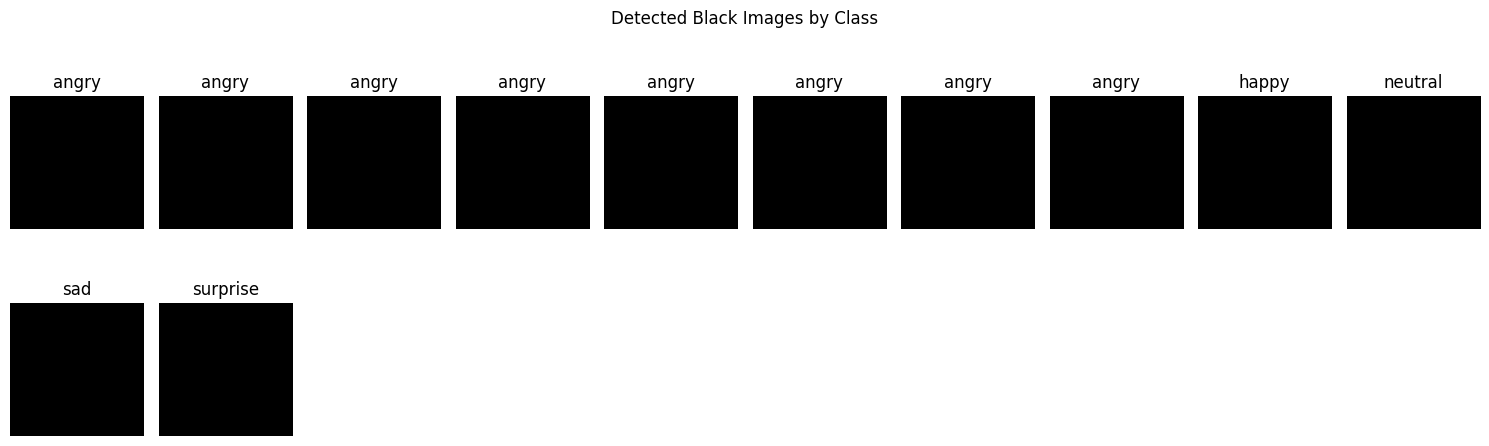

📊 Black image count per class:
angry: 8
happy: 1
neutral: 1
sad: 1
surprise: 1


In [24]:
black_images = find_black_images(fer_dataset)
display_black_images(black_images)
count_black_images_per_class(black_images)

In [25]:
save_black_images(black_images, save_folder=r"D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Exclude Dataset\FER2013\Black Image")

✅ 12 black images saved to 'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Exclude Dataset\FER2013\Black Image'


In [26]:
fer_dataset = remove_black_images(fer_dataset, black_images)

In [27]:
def map_kdef_label(label_code):
    mapping = {
        'AF': 'fear',      
        'AN': 'angry',
        'DI': 'disgust',
        'HA': 'happy',
        'NE': 'neutral',
        'SA': 'sad',
        'SU': 'surprise'
    }
    return mapping.get(label_code.upper(), label_code)

# ============================= 
# Filtering Wajah Pose Frontal, Label Mapping, & Face Cropping KDEF
# ============================= 

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def crop_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(faces) > 0:
        x, y, w, h = faces[0]
        return img[y:y+h, x:x+w] 

    return img

In [ ]:
def read_kdef_frontal_images(folder_path):
    data = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                name, ext = os.path.splitext(filename)

                emotion_code = name[4:6].upper()
                label = map_kdef_label(emotion_code)
                if len(name) > 0 and label is not None and name[-1].upper() == "S":
                    img_path = os.path.join(root, filename)
                    img = cv2.imread(img_path)

                    if img is not None:
                        face = crop_face(img)
                        data.append((face, label))

    return data

# ============================= 
# LOAD & FILTERING FRONTAL KDEF
# ============================= 

In [29]:
kdef_dataset = read_kdef_frontal_images(KDEF_folder_path)

In [30]:
# ===== KDEF =====
total_kdef_used = len(kdef_dataset)
print(f"Total KDEF digunakan (frontal 'S' saja): {total_kdef_used}")

Total KDEF digunakan (frontal 'S' saja): 980


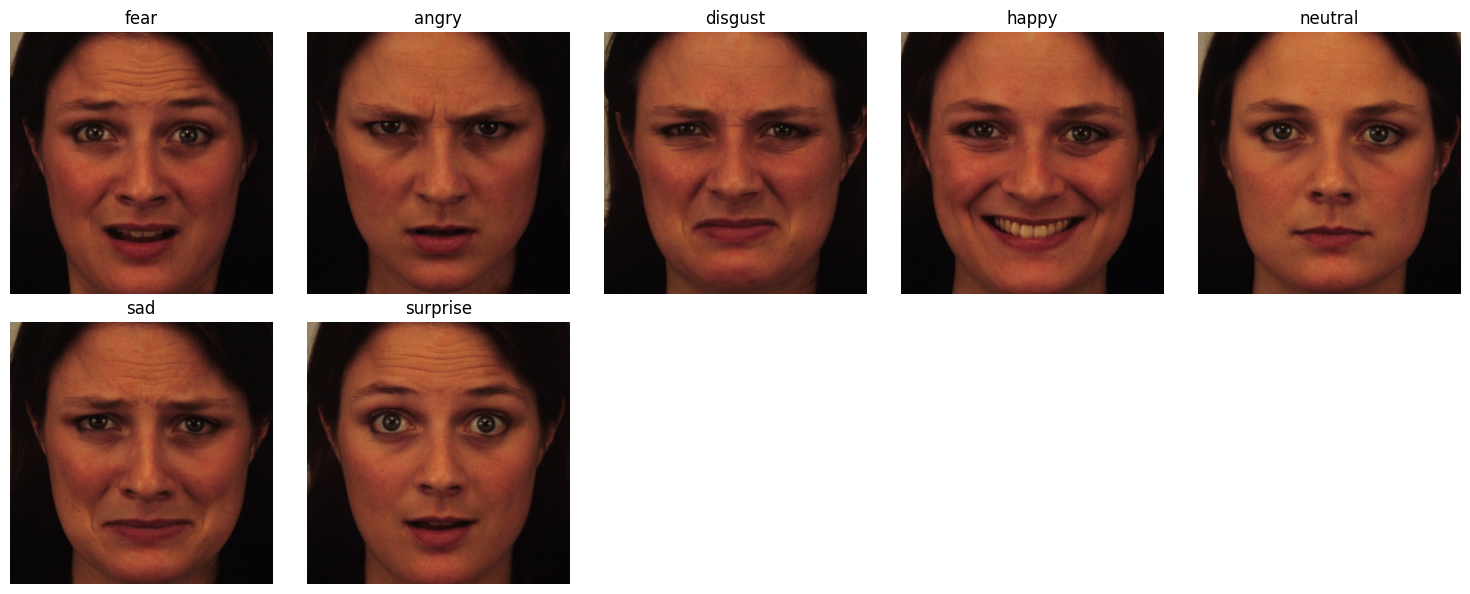

In [ ]:
import matplotlib.pyplot as plt
import cv2

label_images = {}

for img, label in kdef_dataset:
    if label not in label_images:
        label_images[label] = img

plt.figure(figsize=(15, 6))

for i, (label, img) in enumerate(label_images.items()):
    plt.subplot(2, 5, i + 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ============================= 
# Load, Label Mapping & Filtering Label CK+
# ============================= 

In [32]:
# Label Mapping CK+
def read_ckplus_images(folder_path):
    data = []
    label_map = {
        'anger': 'angry',
        'sadness': 'sad'
    }

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    label = os.path.basename(root).lower()
                    label = label_map.get(label, label)  
                    data.append((img, label))
    return data

In [33]:
CK_folder_path = r'D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Raw Dataset\CK+'
ck_dataset = read_ckplus_images(CK_folder_path)

# Filtering Label CK+
ck_dataset = [
    (img, label)
    for img, label in ck_dataset
    if label.lower() != "contempt"
]

print(f"Jumlah Dataset CK+ (tanpa contempt): {len(ck_dataset)}")

Jumlah Dataset CK+ (tanpa contempt): 927


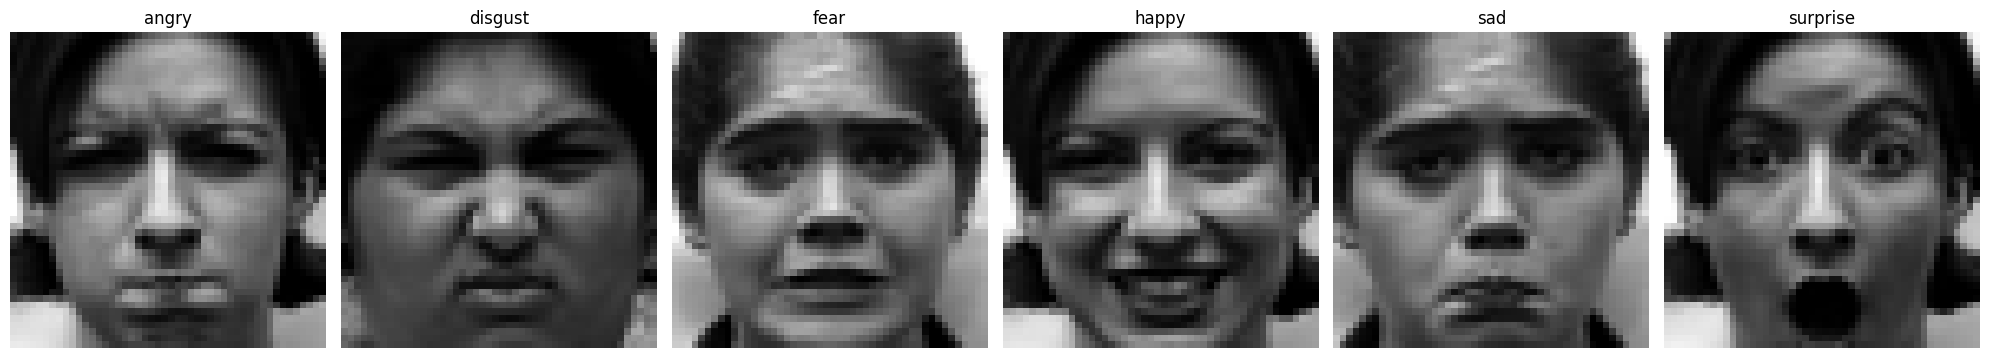

In [ ]:
import matplotlib.pyplot as plt
import cv2

label_images = {}

for img, label in ck_dataset:
    if label not in label_images:
        label_images[label] = img

plt.figure(figsize=(20, 4))

for i, (label, img) in enumerate(label_images.items()):
    plt.subplot(1, len(label_images), i + 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

Cek Label Tiap Dataset

In [35]:
all_labels = [label for _, label in kdef_dataset]
print(set(all_labels))

{'sad', 'neutral', 'disgust', 'angry', 'surprise', 'fear', 'happy'}


In [36]:
all_labels = [label for _, label in fer_dataset]
print(set(all_labels))

{'sad', 'neutral', 'disgust', 'angry', 'surprise', 'fear', 'happy'}


In [37]:
all_labels = [label for _, label in ck_dataset]
print(set(all_labels))

{'sad', 'disgust', 'angry', 'surprise', 'fear', 'happy'}


# ============================= 
## Exploratory Data Analysis Setelah Preprocessing
# ============================= 

In [ ]:
import pandas as pd

label_mapping = {
    "angry": "angry",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "surprise": "surprise",

    # CK+
    "anger": "angry",
    "sadness": "sad",
    "contempt": "contempt",

    # KDEF
    "AF": "fear",
    "AN": "angry",
    "DI": "disgust",
    "HA": "happy",
    "NE": "neutral",
    "SA": "sad",
    "SU": "surprise",
}

def normalize_labels(label_list):
    normalized = []
    
    for lbl in label_list:
        if isinstance(lbl, str):
            normalized.append(
                label_mapping.get(lbl.lower(),
                label_mapping.get(lbl, "Unknown"))
            )
        else:
            normalized.append("Unknown")
            
    return normalized

fer_raw_labels = [label for _, label in fer_dataset]
kdef_raw_labels = [label for _, label in kdef_dataset]
ck_raw_labels = [label for _, label in ck_dataset]

In [ ]:
fer_norm = normalize_labels(fer_raw_labels)
kdef_norm = normalize_labels(kdef_raw_labels)
ck_norm = normalize_labels(ck_raw_labels)
all_labels = fer_norm + kdef_norm + ck_norm

fer_dist = Counter(fer_norm)
kdef_dist = Counter(kdef_norm)
ck_dist = Counter(ck_norm)
total_dist = Counter(all_labels)

print("📦 Jumlah Data per Dataset (EDA After Preprocessing)")
print(f"FER2013 : {len(fer_norm)}")
print(f"KDEF    : {len(kdef_norm)}")
print(f"CK+     : {len(ck_norm)}")
print("----------------------------------")
print(f"TOTAL   : {len(all_labels)}\n")


def print_dist(title, dist):
    print(title)
    
    for k, v in sorted(dist.items(), key=lambda x: -x[1]):
        print(f"{k:<10}: {v}")
        
    print()

print_dist("📊 Distribusi Label FER2013", fer_dist)
print_dist("📊 Distribusi Label KDEF", kdef_dist)
print_dist("📊 Distribusi Label CK+", ck_dist)
print_dist("📊 Distribusi Label Gabungan", total_dist)

df_dist = (
    pd.DataFrame(total_dist.items(), columns=["Emotion", "Jumlah"])
      .sort_values("Jumlah", ascending=False)
      .reset_index(drop=True)
)

print("📋 Tabel Distribusi Label")
print(df_dist)

📦 Jumlah Data per Dataset (EDA After Preprocessing)
FER2013 : 35635
KDEF    : 980
CK+     : 927
----------------------------------
TOTAL   : 37542

📊 Distribusi Label FER2013
happy     : 8948
neutral   : 6181
sad       : 6021
fear      : 5070
angry     : 4902
surprise  : 3971
disgust   : 542

📊 Distribusi Label KDEF
fear      : 140
angry     : 140
disgust   : 140
happy     : 140
neutral   : 140
sad       : 140
surprise  : 140

📊 Distribusi Label CK+
surprise  : 249
happy     : 207
disgust   : 177
angry     : 135
sad       : 84
fear      : 75

📊 Distribusi Label Gabungan
happy     : 9295
neutral   : 6321
sad       : 6245
fear      : 5285
angry     : 5177
surprise  : 4360
disgust   : 859

📋 Tabel Distribusi Label
    Emotion  Jumlah
0     happy    9295
1   neutral    6321
2       sad    6245
3      fear    5285
4     angry    5177
5  surprise    4360
6   disgust     859


In [41]:
combined_dataset = fer_dataset + kdef_dataset + ck_dataset
print(f"Total gabungan FER2013 + CK+ + KDEF (Setelah Filtering Dataset): {len(combined_dataset)}")

Total gabungan FER2013 + CK+ + KDEF (Setelah Filtering Dataset): 37542


In [ ]:
combined_dataset_gray = []

for img, label in combined_dataset:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    combined_dataset_gray.append((img, label))

In [43]:
del combined_dataset

Jumlah data per label setelah dilakukan proses combine:
happy: 9295
neutral: 6321
sad: 6245
fear: 5285
angry: 5177
surprise: 4360
disgust: 859


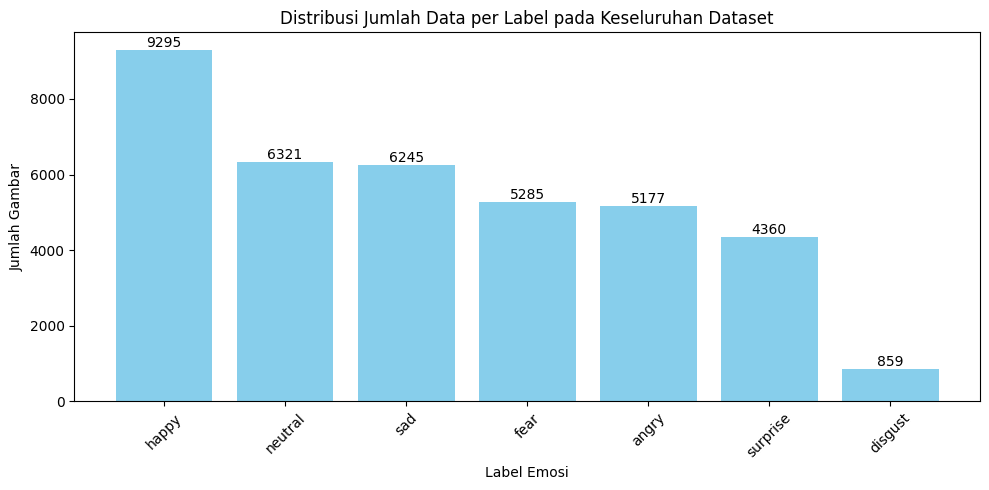

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

all_labels = [label for _, label in combined_dataset_gray]

label_counts = Counter(all_labels)
sorted_label_counts = label_counts.most_common()
labels_sorted, values = zip(*sorted_label_counts)

print("Jumlah data per label setelah dilakukan proses combine:")
for label, count in sorted_label_counts:
    print(f"{label}: {count}")

plt.figure(figsize=(10, 5))
bars = plt.bar(labels_sorted, values, color='skyblue')
plt.bar_label(bars)

plt.title('Distribusi Jumlah Data per Label pada Keseluruhan Dataset')
plt.xlabel('Label Emosi')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
def print_sample_image_size(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    h, w = img.shape[:2]
                    print(f"Sample image: {filename}")
                    print(f"Size: {w}x{h} px")
                    return

In [46]:
def apply_histogram_equalization(gray):
    return cv2.equalizeHist(gray)

In [47]:
def apply_contrast_stretching(gray):
  
    min_val = gray.min()
    max_val = gray.max()

    if max_val - min_val == 0:
        stretched = gray
    else:
        stretched = ((gray - min_val) / (max_val - min_val) * 255).astype(np.uint8)

    return stretched

In [48]:
def apply_cs_he(gray):
    cs = apply_contrast_stretching(gray)
    return cv2.equalizeHist(cs)

# ============================= 
# Data Splitting
# ============================= 

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split  

all_labels = [label for _, label in combined_dataset_gray]

label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

train_data, temp_data, train_labels, temp_labels = train_test_split(
    combined_dataset_gray,
    all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

In [50]:
print("📦 Distribusi Jumlah Data:")
print(f"Train: {len(train_data)}")
print(f"Validation: {len(val_data)}")
print(f"Test: {len(test_data)}")

📦 Distribusi Jumlah Data:
Train: 26279
Validation: 5631
Test: 5632


In [51]:
from collections import Counter

def print_label_distribution(data, title):
    labels = [label for _, label in data]
    counts = Counter(labels)
    sorted_label_counts = counts.most_common()
    labels_sorted, values = zip(*sorted_label_counts)

    print(f"\n📊 Distribusi Label - {title}")
    total = sum(counts.values())
    for label, count in counts.items():
        print(f"{label:10s}: {count:5d} ({count/total*100:.2f}%)")

In [52]:
print_label_distribution(train_data, "Train")
print_label_distribution(val_data, "Validation")
print_label_distribution(test_data, "Test")


📊 Distribusi Label - Train
neutral   :  4425 (16.84%)
happy     :  6506 (24.76%)
angry     :  3624 (13.79%)
fear      :  3700 (14.08%)
sad       :  4371 (16.63%)
disgust   :   601 (2.29%)
surprise  :  3052 (11.61%)

📊 Distribusi Label - Validation
sad       :   937 (16.64%)
fear      :   792 (14.06%)
happy     :  1394 (24.76%)
neutral   :   948 (16.84%)
surprise  :   654 (11.61%)
angry     :   777 (13.80%)
disgust   :   129 (2.29%)

📊 Distribusi Label - Test
sad       :   937 (16.64%)
angry     :   776 (13.78%)
neutral   :   948 (16.83%)
fear      :   793 (14.08%)
surprise  :   654 (11.61%)
happy     :  1395 (24.77%)
disgust   :   129 (2.29%)


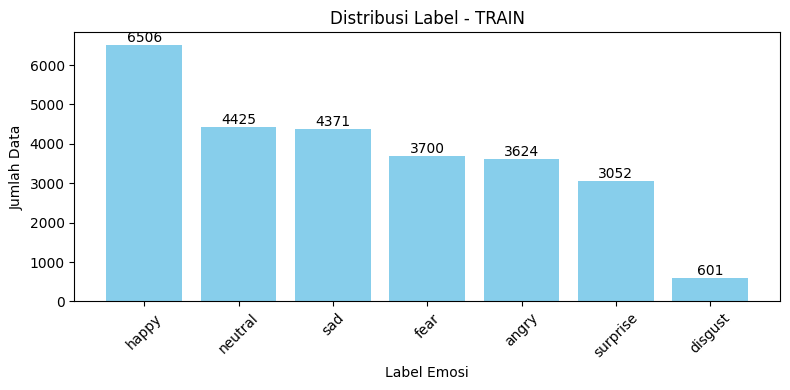

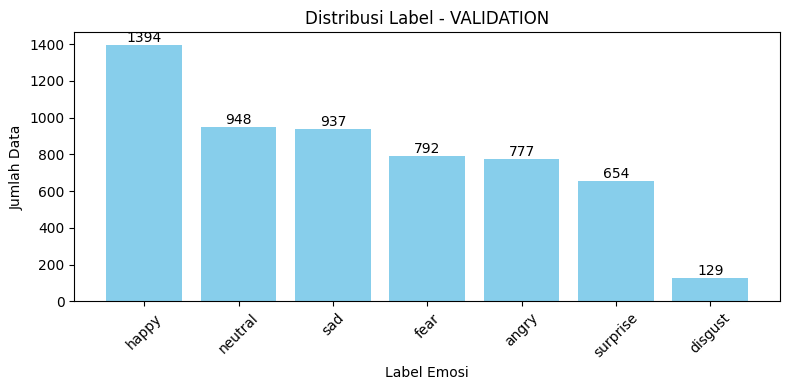

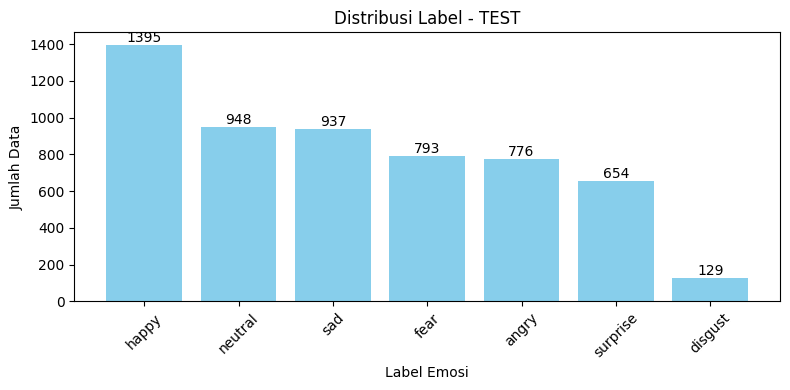

In [53]:
import matplotlib.pyplot as plt

def plot_label_distribution(data, title):
    labels = [label for _, label in data]
    counts = Counter(labels)

    sorted_labels_counts = counts.most_common()
    labels_sorted, values = zip(*sorted_labels_counts)

    plt.figure(figsize=(8,4))
    plt.bar(labels_sorted, values)

    bars = plt.bar(labels_sorted, values, color='skyblue')
    plt.bar_label(bars)

    plt.title(f"Distribusi Label - {title}")
    plt.xlabel("Label Emosi")
    plt.ylabel("Jumlah Data")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_label_distribution(train_data, "TRAIN")
plot_label_distribution(val_data, "VALIDATION")
plot_label_distribution(test_data, "TEST")

In [ ]:
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class_counts = Counter([label for _, label in train_data])
max_count = max(class_counts.values())
augment_multiplier = {cls: max_count // count for cls, count in class_counts.items()}

# Augmentor
augmentor = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=[0.8, 1.2],
    horizontal_flip=True
)

#  HE / CS / CS - HE, Resized & Convert to RGB, Data Augmentation, Preprocess_input Library, Label Encoding & One Hot Encoding

In [ ]:
def data_generator(
    data, label_encoder, batch_size=32, method="raw", shuffle=True, augment=False
):
    num_samples = len(data)

    while True:
        if shuffle:
            np.random.shuffle(data)

        for offset in range(0, num_samples, batch_size):
            batch_samples = data[offset : offset + batch_size]

            images = []
            labels = []

            for img, label in batch_samples:
                # ===============================
                # IMAGE ENHANCEMENT
                # ===============================
                if method == "raw":
                    img_p = img
 
                elif method == "hist_eq":
                    img_p = apply_histogram_equalization(img)

                elif method == "contrast_stretch":
                    img_p = apply_contrast_stretching(img)

                elif method == "cs_he":
                    img_p = apply_cs_he(img)

                else:
                    raise ValueError(f"Unknown method: {method}")

                # ===============================
                # RESIZE + Conv to BGR
                # ===============================
                img_p = cv2.resize(img_p, (224, 224))
                img_p = cv2.cvtColor(img_p, cv2.COLOR_GRAY2RGB)

                # ===============================
                # DATA AUGMENTATION (TRAIN)
                # ===============================
                if augment:
                    for _ in range(max(1, augment_multiplier[label])):
                        aug_img = augmentor.random_transform(img_p)
                        aug_img = preprocess_input(aug_img.astype(np.float32))
                        images.append(aug_img)
                        labels.append(label)
                        
                # Preprocessing Input ResNet-50
                else:
                    img_p = preprocess_input(img_p.astype(np.float32))
                    images.append(img_p)
                    labels.append(label)

            # ===============================
            # LABEL ENCODING
            # ===============================
            y_encoded = label_encoder.transform(labels)
            y_onehot = tf.keras.utils.to_categorical(
                y_encoded, num_classes=len(label_encoder.classes_)
            )

            yield np.array(images, dtype=np.float32), y_onehot


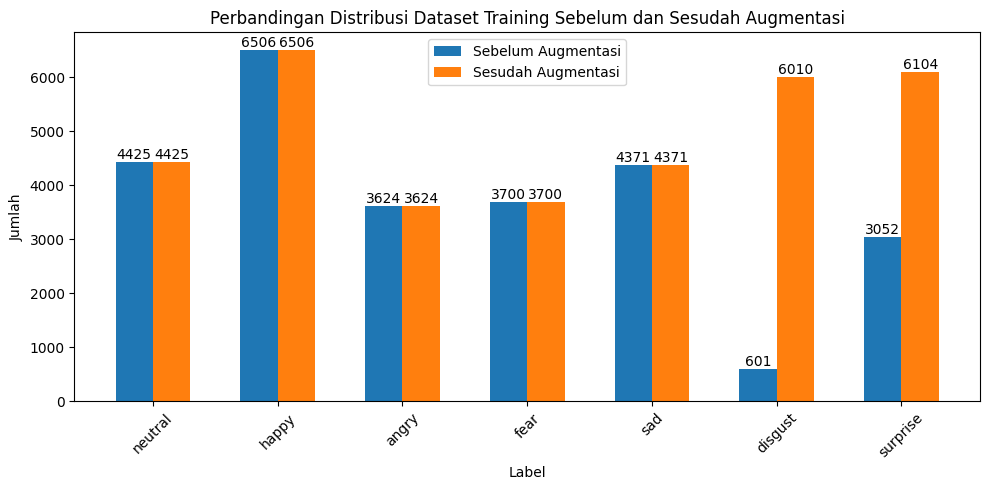

In [56]:
from collections import Counter

original_counts = Counter()
for _, label in train_data:
    original_counts[label] += 1

augmented_counts = Counter()
for _, label in train_data:
    augmented_counts[label] += augment_multiplier[label]

labels = list(original_counts.keys())
original_values = [original_counts[l] for l in labels]
augmented_values = [augmented_counts[l] for l in labels]

x = np.arange(len(labels))
width = 0.30

plt.figure(figsize=(10,5))


bars_1 = plt.bar(x - width/2, original_values, width=width, label='Sebelum Augmentasi')
bars_2 = plt.bar(x + width/2, augmented_values, width=width, label='Sesudah Augmentasi')

plt.bar_label(bars_1)
plt.bar_label(bars_2)

plt.title("Perbandingan Distribusi Dataset Training Sebelum dan Sesudah Augmentasi")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(x, labels, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
batch_size = 32

train_generator = data_generator(
    train_data,
    label_encoder,
    batch_size=batch_size,
    method='raw',
    shuffle=True,
    augment=True,
)

val_generator = data_generator(
    val_data,
    label_encoder,
    batch_size=batch_size,
    method='raw',
    shuffle=False,
    augment=False    
)

train_steps = len(train_data) // batch_size
val_steps = len(val_data) // batch_size


In [58]:
X_batch, y_batch = next(train_generator)
print(f"Resized sample size: {X_batch   [0].shape[1]}x{X_batch[0].shape[0]} px")

Resized sample size: 224x224 px


In [59]:
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [60]:
pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

pretrained_model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [61]:
# Freeze all layers
for layer in pretrained_model.layers:
    layer.trainable = False

resnet_model = models.Sequential([
    pretrained_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(7, activation='softmax')
])

In [62]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 batch_normalization_1 (Batc  (None, 128)              5

# Klasifikasi CNN 

In [63]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint1 = ModelCheckpoint(
    "best_classifier.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)                                                                           

history_classifier = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=50,
    callbacks=[checkpoint1],
    verbose=1

)

Epoch 1/50
821/821 [==============================] - ETA: 0s - loss: 1.6331 - accuracy: 0.4349
Epoch 1: val_loss improved from inf to 1.35657, saving model to best_classifier.h5
821/821 [==============================] - 160s 190ms/step - loss: 1.6331 - accuracy: 0.4349 - val_loss: 1.3566 - val_accuracy: 0.4929
Epoch 2/50
821/821 [==============================] - ETA: 0s - loss: 1.3472 - accuracy: 0.5190
Epoch 2: val_loss improved from 1.35657 to 1.27792, saving model to best_classifier.h5
821/821 [==============================] - 156s 190ms/step - loss: 1.3472 - accuracy: 0.5190 - val_loss: 1.2779 - val_accuracy: 0.5179
Epoch 3/50
821/821 [==============================] - ETA: 0s - loss: 1.2688 - accuracy: 0.5446
Epoch 3: val_loss improved from 1.27792 to 1.26128, saving model to best_classifier.h5
821/821 [==============================] - 156s 190ms/step - loss: 1.2688 - accuracy: 0.5446 - val_loss: 1.2613 - val_accuracy: 0.5286
Epoch 4/50
821/821 [==============================

In [64]:
total_layers = len(pretrained_model.layers)
unfreeze_from = total_layers // 2

In [65]:
for i, layer in enumerate(pretrained_model.layers):
    if i >= unfreeze_from:
        layer.trainable = True
    else:
        layer.trainable = False

In [66]:
print("Total layers:", total_layers)
print("Trainable layers:", sum(
    layer.trainable for layer in pretrained_model.layers
))

Total layers: 175
Trainable layers: 88


In [67]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [68]:
checkpoint2 = ModelCheckpoint(
    "best_finetuned_resnet.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [69]:
history_finetune = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    initial_epoch=50,
    epochs=100,
    callbacks=[checkpoint2],
    verbose=1
)

Epoch 51/100
821/821 [==============================] - ETA: 0s - loss: 1.2428 - accuracy: 0.5650
Epoch 51: val_loss improved from inf to 1.18693, saving model to best_finetuned_resnet.h5
821/821 [==============================] - 187s 224ms/step - loss: 1.2428 - accuracy: 0.5650 - val_loss: 1.1869 - val_accuracy: 0.5682
Epoch 52/100
821/821 [==============================] - ETA: 0s - loss: 1.0168 - accuracy: 0.6350
Epoch 52: val_loss improved from 1.18693 to 1.11651, saving model to best_finetuned_resnet.h5
821/821 [==============================] - 159s 193ms/step - loss: 1.0168 - accuracy: 0.6350 - val_loss: 1.1165 - val_accuracy: 0.5939
Epoch 53/100
821/821 [==============================] - ETA: 0s - loss: 0.9135 - accuracy: 0.6704
Epoch 53: val_loss improved from 1.11651 to 1.07229, saving model to best_finetuned_resnet.h5
821/821 [==============================] - 159s 194ms/step - loss: 0.9135 - accuracy: 0.6704 - val_loss: 1.0723 - val_accuracy: 0.6177
Epoch 54/100
821/821 [=

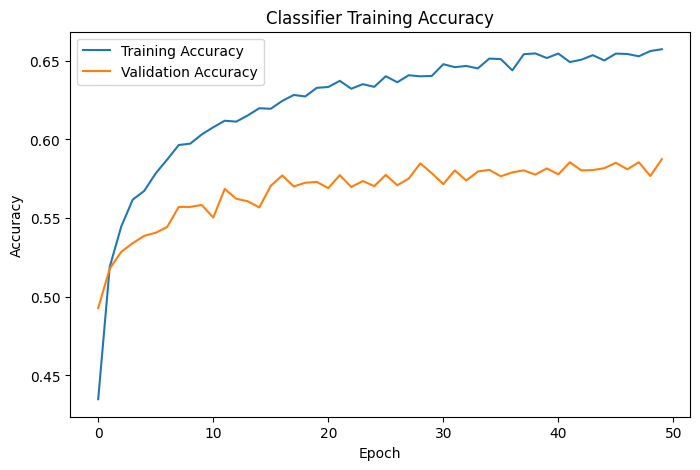

In [70]:
# Classifier Training - Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_classifier.history['accuracy'], label='Training Accuracy')
plt.plot(history_classifier.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classifier Training Accuracy')
plt.legend()
plt.show()

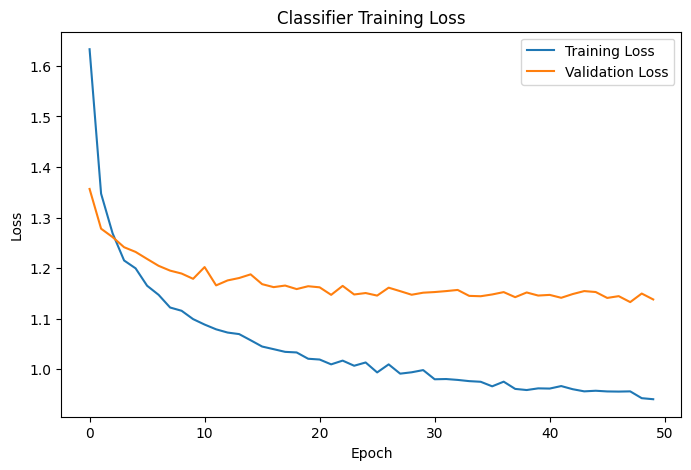

In [71]:
# Classifier Training - Loss
plt.figure(figsize=(8,5))
plt.plot(history_classifier.history['loss'], label='Training Loss')
plt.plot(history_classifier.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Classifier Training Loss')
plt.legend()
plt.show()

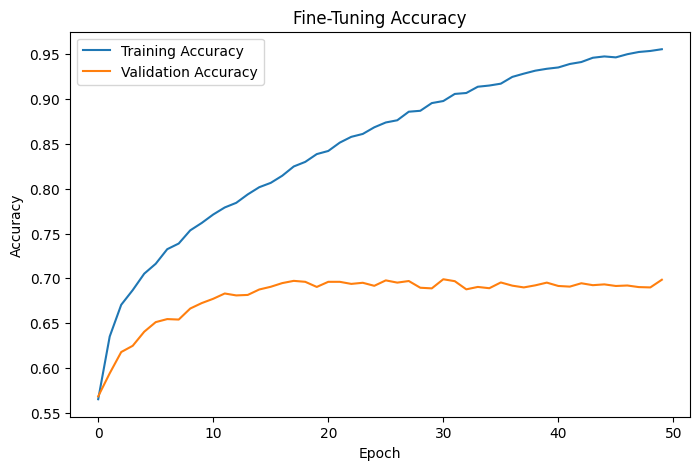

In [72]:
# Fine-Tuning - Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.legend()
plt.show()

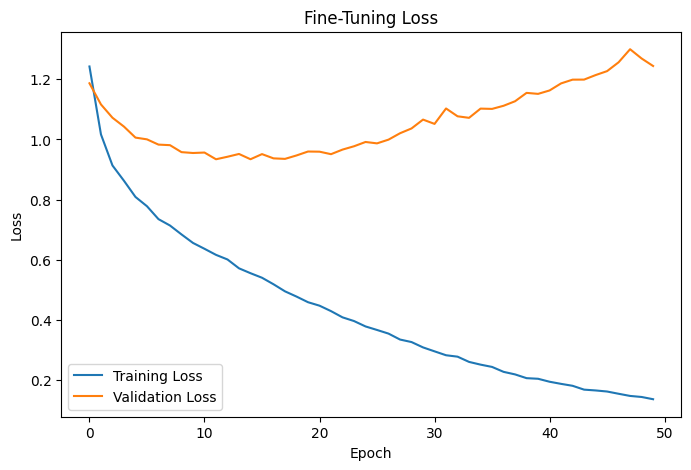

In [73]:
# Fine-Tuning - Loss
plt.figure(figsize=(8,5))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss')
plt.legend()
plt.show()

In [74]:
test_generator = data_generator(
    test_data,
    label_encoder,
    batch_size=batch_size,
    method='raw',
    shuffle=False,
    augment=False     
)

test_steps = int(np.ceil(len(test_data) / batch_size))

In [75]:
y_pred_prob = resnet_model.predict(
    test_generator,
    steps=test_steps,
    verbose=1
)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = label_encoder.transform(test_labels)

176/176 [==============================] - 10s 52ms/step


In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Akurasi Test: {accuracy * 100:.2f}%")

Akurasi Test: 70.81%


In [77]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Breakdown per label:")
for i, label in enumerate(label_encoder.classes_):
    benar = cm[i, i]
    total = cm[i].sum()
    salah = total - benar
    print(f"{label}: Benar = {benar}, Salah = {salah}, Total = {total}")


Breakdown per label:
angry: Benar = 488, Salah = 288, Total = 776
disgust: Benar = 82, Salah = 47, Total = 129
fear: Benar = 416, Salah = 377, Total = 793
happy: Benar = 1247, Salah = 148, Total = 1395
neutral: Benar = 639, Salah = 309, Total = 948
sad: Benar = 574, Salah = 363, Total = 937
surprise: Benar = 542, Salah = 112, Total = 654


# ============================= 
# Confusion Matrix  (Evaluasi Kinerja Sistem)
# ============================= 

              precision    recall  f1-score   support

       angry       0.65      0.63      0.64       776
     disgust       0.85      0.64      0.73       129
        fear       0.66      0.52      0.58       793
       happy       0.84      0.89      0.87      1395
     neutral       0.62      0.67      0.65       948
         sad       0.59      0.61      0.60       937
    surprise       0.80      0.83      0.81       654

    accuracy                           0.71      5632
   macro avg       0.72      0.69      0.70      5632
weighted avg       0.71      0.71      0.71      5632



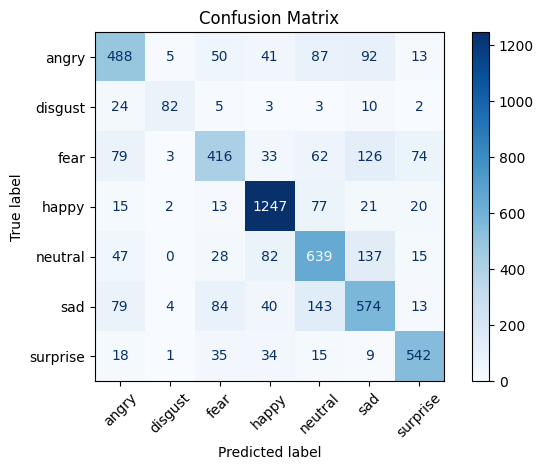

In [78]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Demo (Predict Model)

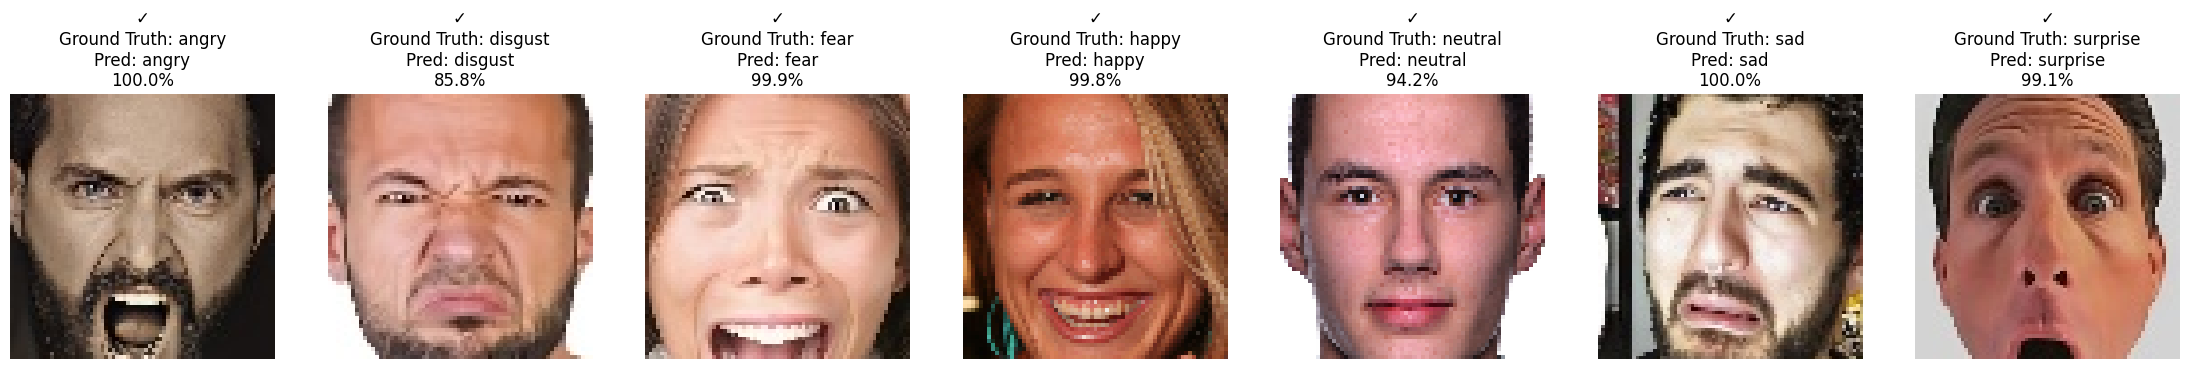

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

folder_path = r"D:\SKRIPSI ALFARIZA\Dataset\Final Dataset\Demo Dataset\Final"  

# load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

n = len(image_files)
plt.figure(figsize=(4*n, 4))

for i, filename in enumerate(image_files):
    img_path = os.path.join(folder_path, filename)
    
    img = cv2.imread(img_path)

    true_label = filename.split(".")[0]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        face_img = img  
    else:
        x, y, w, h = faces[0]
        face_img = img[y:y+h, x:x+w]

    img_p = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    img_p = cv2.resize(img_p, (224,224))
    img_p = cv2.cvtColor(img_p, cv2.COLOR_GRAY2BGR)
    img_p = preprocess_input(img_p.astype(np.float32))
    img_p = np.expand_dims(img_p, axis=0)

    prob = resnet_model.predict(img_p, verbose=0)
    pred_idx = np.argmax(prob)
    conf = np.max(prob) * 100
    pred_label = label_encoder.classes_[pred_idx]

    status = "✓" if true_label.lower() == pred_label.lower() else "✗"

    plt.subplot(1, n, i+1)
    plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    plt.title(
        f"{status}\n"
        f"Ground Truth: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"{conf:.1f}%"
    )
    plt.axis('off')

plt.show()